# Multi-tissue classification Ovarian cancer

**Table of Contents**                                                                      
Step1: Environment Setup                                                                          
Step2: Data Loading and Preparation                                                                      
Step3: Analyzing Class Distribution                                                          
Step4: Data Augmentation                                                           
Step5: Splitting the Dataset                                                                                     
Step6: Preparing Data Generators                                                             
Step7: Building the Model                                                                                       
Step8: Compiling the Model                                                 
Step9: Implementing Learning Rate Scheduling and Early Stopping                                      
Step10: Training the Model                                                             
Step11: Evaluating the Model                                                                   
Step12: Conclusion and Next Steps                                                           



**Step: 1 Environment Setup**

In [78]:
# Data manipulation and analysis
import os 
os.environ["KERAS_BACKEND"] = "jax"  # @param ["tensorflow", "jax", "torch"]

import numpy as np
import pandas as pd
from glob import glob

# Image processing
from PIL import Image
import cv2


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, MaxPool2D, Input
from tensorflow.keras.layers import Layer, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.layers import Input, Embedding, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import preprocess_input


from tensorflow.keras.utils import to_categorical

import keras
from keras import layers
from keras import ops


# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Loading Data**


In [79]:
# Assuming the dataset is in a folder named 'dataset'
data_dir = '/kaggle/input/tcga-ovarian-histological-images/ovarian'

# Get class names from subdirectory names
classes = sorted([d.name for d in os.scandir(data_dir) if d.is_dir()])
print("Classes:", classes)


# Initialize lists to hold file paths and labels
image_paths = []
image_labels = []

# Map class names to numerical labels
class_to_label = {class_name: idx for idx, class_name in enumerate(classes)}
print("Class to label mapping:", class_to_label)

# Loop through each class directory and collect file paths
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    # Get all image file paths in the class directory
    image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith('.jpg')]
    # Append file paths and labels
    image_paths.extend(image_files)
    image_labels.extend([class_to_label[class_name]] * len(image_files))
    #print(f"Processing {len(image_files)} images for class '{class_name}'")

print(f"Total images found: {len(image_paths)}")

Classes: ['non-tumour', 'tumour']
Class to label mapping: {'non-tumour': 0, 'tumour': 1}
Total images found: 33110


**3. Analyzing Class Distribution**

Class counts:
 class_name
tumour        19747
non-tumour    13363
Name: count, dtype: int64


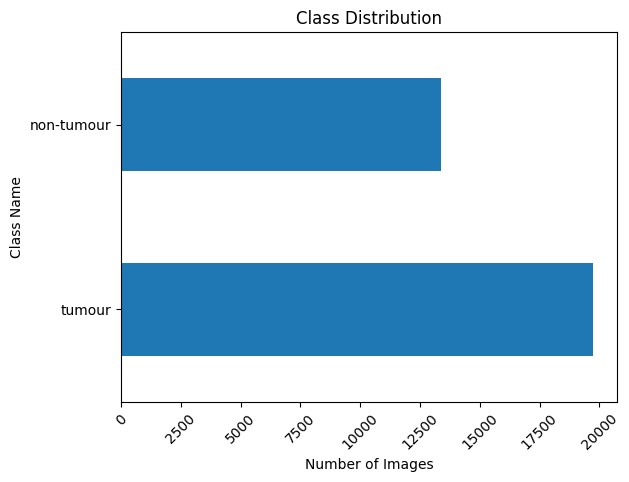

In [80]:
# Create a DataFrame to aid in analysis
df = pd.DataFrame({
    'image_path': image_paths,
    'label': image_labels
})

# Map numerical labels to class names
label_to_class = {v: k for k, v in class_to_label.items()}
df['class_name'] = df['label'].map(label_to_class)

# Display class counts
class_counts = df['class_name'].value_counts()
print("Class counts:\n", class_counts)

# Plot class distribution
class_counts.plot(kind='barh')
plt.title('Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.xticks(rotation=45)
plt.show() 



In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33110 entries, 0 to 33109
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  33110 non-null  object
 1   label       33110 non-null  int64 
 2   class_name  33110 non-null  object
dtypes: int64(1), object(2)
memory usage: 776.1+ KB


In [82]:
df.head()

,image_path,label,class_name
0,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
1,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
2,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
3,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
4,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour


In [83]:
df.tail()

,image_path,label,class_name
33105,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33106,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33107,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33108,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33109,/kaggle/input/tcga-ovarian-histological-images...,1,tumour


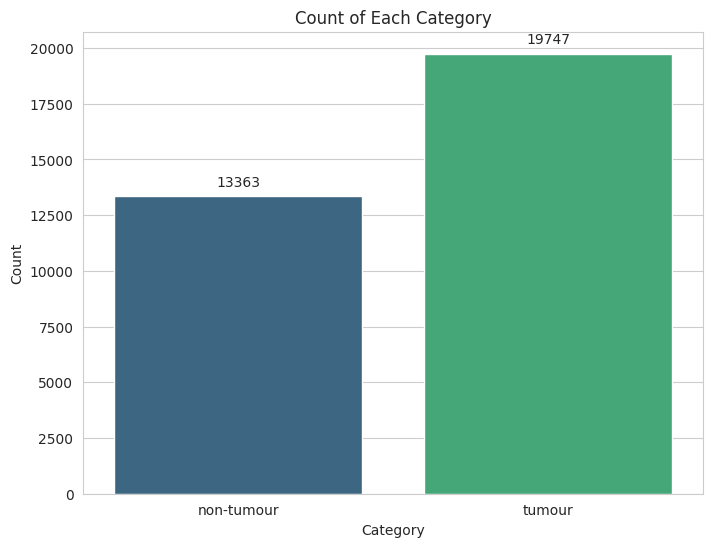

In [84]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x=df['label'].map(label_to_class), palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center',
                va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')

plt.title("Count of Each Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

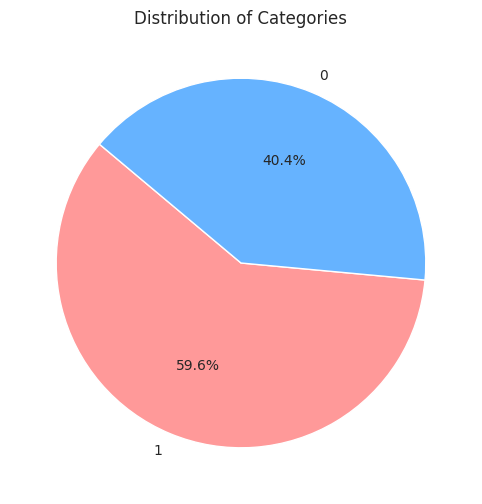

In [85]:
#Show distribution of classes in pye chart
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])

plt.title("Distribution of Categories")

plt.show() 

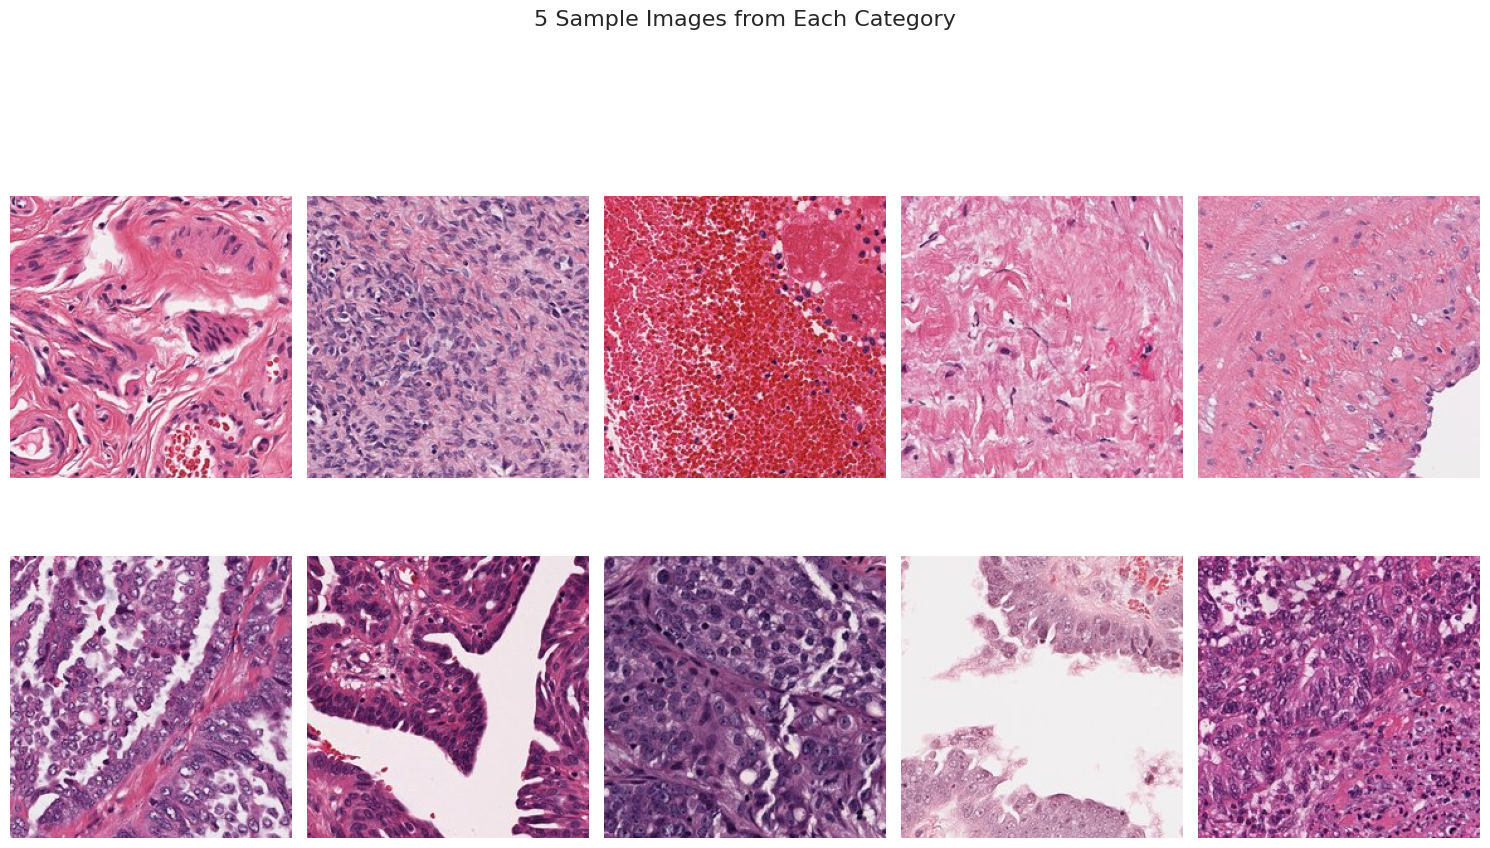

In [86]:
num_images = 5

fig, axes = plt.subplots(len(label_to_class), num_images, figsize=(15, 10))
fig.suptitle("5 Sample Images from Each Category", fontsize=16)

for i, category in enumerate(label_to_class):

    sample_images = df[df['label'] == category].sample(num_images) #random_state = 42

    for j, image_path in enumerate(sample_images['image_path']):

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(category, fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
     


**Step 5: Split the Dataset**


In [87]:
# Split into training 80% and temp 20% (validation 10% + test 10%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42,
    shuffle = True
)

# Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42,
    shuffle = True
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")





Training set size: 26488
Validation set size: 3311
Test set size: 3311


**6. Preparing Data Generators**


6.1. Training Data Generator


In [88]:
# Define image data generator with augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    #validation_split=0.1,  # Split for validation
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

# Load training and validation data
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training',  # Set as training data
    shuffle=True
)

Found 26488 validated image filenames belonging to 2 classes.


In [89]:
val_gen = ImageDataGenerator(rescale=1./255)
validation_generator = val_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

Found 3311 validated image filenames belonging to 2 classes.


In [95]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 64
num_epochs = 25  # For real training, use num_epochs=100. 10 is a test value
image_size = 224  # We'll resize input images to this size
patch_size = 20  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifier


In [96]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


In [97]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size
    #(None,224,224,3)
    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

In [98]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config


**9. Building and Configuring the ViT Model**

In [123]:
input_shape = (224, 224, 3)
num_classes = 2  # Set this to the number of classes in your dataset
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Create patches.
    patches = Patches(patch_size)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    model.summary()
    return model


In [125]:
vit_classifier = create_vit_classifier()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10            │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patches_7 (Patches)       │ (None, 121, 1200)      │              0 │ input_layer_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patch_encoder_7           │ (None, 121, 64)        │         84,608 │ patches_7[0][0]        │
│ (PatchEncoder)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_119   │ (None, 121, 64)        │            128 │ patch_encoder_7[0][0]  │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_56   │ (None, 121, 64)        │         66,368 │ layer_normalization_1… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_112 (Add)             │ (None, 121, 64)        │              0 │ multi_head_attention_… │
│                           │                        │                │ patch_encoder_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_120   │ (None, 121, 64)        │            128 │ add_112[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_141 (Dense)         │ (None, 121, 128)       │          8,320 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_190 (Dropout)     │ (None, 121, 128)       │              0 │ dense_141[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_142 (Dense)         │ (None, 121, 64)        │          8,256 │ dropout_190[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_191 (Dropout)     │ (None, 121, 64)        │              0 │ dense_142[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_113 (Add)             │ (None, 121, 64)        │              0 │ dropout_191[0][0],     │
│                           │                        │                │ add_112[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_121   │ (None, 121, 64)        │            128 │ add_113[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_57   │ (None, 121, 64)        │         66,368 │ layer_normalization_1… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_114 (Add)             │ (None, 121, 64)        │              0 │ multi_head_attention_… │
│                      

 Total params: 18,712,322 (71.38 MB)

 Trainable params: 18,712,322 (71.38 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
def run_experiment(model):
    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            
        ],
    )
    
    checkpoint_filepath = "/kaggle/working/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        train_generator,
        batch_size=batch_size,
        validation_data=validation_generator,
        epochs=num_epochs,
        callbacks=[checkpoint_callback],
    )
    
    
    
    return history





In [102]:
history = vit_classifier.fit(
        train_generator,
        batch_size=batch_size,
        validation_data=validation_generator,
        epochs=num_epochs,
        callbacks=[checkpoint_callback],
)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
413/414 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.6606 - loss: 1.5164

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


414/414 ━━━━━━━━━━━━━━━━━━━━ 317s 741ms/step - accuracy: 0.6610 - loss: 1.5126 - val_accuracy: 0.8411 - val_loss: 0.3737
Epoch 2/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 291s 688ms/step - accuracy: 0.8307 - loss: 0.3980 - val_accuracy: 0.8747 - val_loss: 0.3169
Epoch 3/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 285s 687ms/step - accuracy: 0.8505 - loss: 0.3651 - val_accuracy: 0.8774 - val_loss: 0.2996
Epoch 4/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 286s 690ms/step - accuracy: 0.8564 - loss: 0.3462 - val_accuracy: 0.8873 - val_loss: 0.2893
Epoch 5/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 283s 683ms/step - accuracy: 0.8727 - loss: 0.3227 - val_accuracy: 0.8638 - val_loss: 0.3321
Epoch 6/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 284s 685ms/step - accuracy: 0.8859 - loss: 0.2912 - val_accuracy: 0.9106 - val_loss: 0.2299
Epoch 7/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 285s 688ms/step - accuracy: 0.8951 - loss: 0.2717 - val_accuracy: 0.9136 - val_loss: 0.2141
Epoch 8/25
414/414 ━━━━━━━━━━━━━━━━━━━━ 283s 682ms/step - accuracy: 0.9081 - loss: 0.25

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 333ms/step - accuracy: 0.9559 - loss: 0.1274


ValueError: not enough values to unpack (expected 3, got 2)

In [133]:
# Evaluate the model using the test set
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
    )

    
vit_classifier.load_weights(checkpoint_filepath)
test_loss, test_accuracy = vit_classifier.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Found 3311 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9559 - loss: 0.1274
Test Accuracy: 96.04%


In [140]:
test_labels = test_generator.classes
predictions = vit_classifier.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
     

report = classification_report(test_labels, predicted_classes, target_names=list(test_generator.class_indices.keys()))
print(report)
     


52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step
              precision    recall  f1-score   support

  non-tumour       0.96      0.94      0.95      1336
      tumour       0.96      0.97      0.97      1975

    accuracy                           0.96      3311
   macro avg       0.96      0.96      0.96      3311
weighted avg       0.96      0.96      0.96      3311



In [141]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

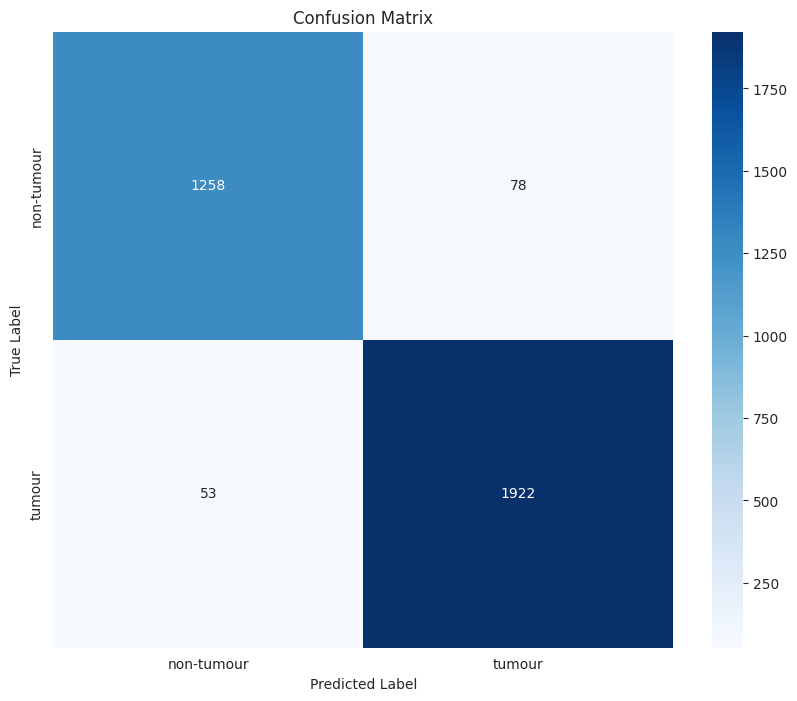

In [142]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_generator.class_indices.keys()), yticklabels=list(test_generator.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
vit_classifier.save('model.h5')
vit_classifier.save('model.keras')